# QDIST v4.1.0 — full candidate-cohort validation

This notebook recomputes QDIST from frozen segmentation and the native decoded first audio stream. The valid construct is **visible hard-plateau morphology in the stored decoded waveform**. It does not identify a physical stage and does not measure all nonlinear distortion.

Candidate roles: sample support = primary; event rate = secondary; 30-ms frame fraction = conditional/audit. Clinical labels and human-QC labels are prohibited. Publication and freeze are hard-disabled.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'config' / 'project.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not locate config/project.yaml above the notebook working directory.')

ROOT = find_project_root(Path.cwd())
for source in [ROOT / 'src', ROOT / 'src']:
    if str(source) not in sys.path:
        sys.path.insert(0, str(source))

from paper1_qc_reviewed.qdist_v410_cohort import (
    CohortPaths, REQUIRED_MAIN_PANELS, run_candidate_cohort,
)
print('Project root:', ROOT)

Project root: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1


## Governed run controls

Leave the scientific decision pending. `RESUME=True` is safe because checkpoints are content-addressed by detector, media code, parameters, and frozen inputs.

In [2]:
RESUME = True
REBUILD_BLIND_REVIEW = False
RUN_REAL_SPEECH_CHALLENGES = True
RUN_PARAMETER_ROBUSTNESS = True
SCIENTIFIC_REVIEW_DECISION = 'PENDING'
PUBLISH_AND_FREEZE = False

assert SCIENTIFIC_REVIEW_DECISION == 'PENDING'
assert PUBLISH_AND_FREEZE is False

In [3]:
paths = CohortPaths.from_project_root(ROOT)
preflight_manifest_path = (
    paths.preflight_root / 'manifests' / 'qdist_v410_remediation_preflight_manifest.json'
)
if not preflight_manifest_path.exists():
    raise FileNotFoundError('Accepted QDIST v4.1 remediation preflight is required before cohort validation.')
preflight_manifest = json.loads(preflight_manifest_path.read_text(encoding='utf-8'))
display(pd.Series({
    key: preflight_manifest.get(key) for key in [
        'measurement_version', 'blocking_remediation_checks_pass',
        'package_tests_passed', 'candidate_only', 'freeze_allowed',
        'detector_sha256', 'parameter_hash',
    ]
}).rename('preflight'))

measurement_version                                            qdist-v4.1.0-candidate
blocking_remediation_checks_pass                                                 True
package_tests_passed                                                             True
candidate_only                                                                   True
freeze_allowed                                                                  False
detector_sha256                     38eccffda5b71b7d7542b8d79d6cbb4d0567daa9594e0c...
parameter_hash                      12076d5e0a33e102255915b07010d5c1a1be050ab0e809...
Name: preflight, dtype: object

## Full candidate-cohort run

This is the long-running cell. It performs native recomputation, exact reconstruction, the v3.1.1 comparison, matched-burden cohort-speech challenges, support calibration, 23 prespecified parameter settings, participant/repeat analyses, blinded-review generation, and Panels D–J. A stopped run can be restarted with `RESUME=True`.

In [4]:
result = run_candidate_cohort(
    ROOT,
    resume=RESUME,
    rebuild_review=REBUILD_BLIND_REVIEW,
    run_real_speech_challenges=RUN_REAL_SPEECH_CHALLENGES,
    run_parameter_robustness=RUN_PARAMETER_ROBUSTNESS,
    publish_and_freeze=PUBLISH_AND_FREEZE,
)
display(pd.Series(result['manifest'], name='candidate cohort manifest'))

QDIST v4.1 25/519 | 4.22 recordings/s | ETA 2.0 min
QDIST v4.1 50/519 | 4.39 recordings/s | ETA 1.8 min
QDIST v4.1 75/519 | 4.25 recordings/s | ETA 1.7 min
QDIST v4.1 100/519 | 4.08 recordings/s | ETA 1.7 min
QDIST v4.1 125/519 | 4.15 recordings/s | ETA 1.6 min
QDIST v4.1 150/519 | 4.11 recordings/s | ETA 1.5 min
QDIST v4.1 175/519 | 4.14 recordings/s | ETA 1.4 min
QDIST v4.1 200/519 | 4.17 recordings/s | ETA 1.3 min
QDIST v4.1 225/519 | 3.94 recordings/s | ETA 1.2 min
QDIST v4.1 250/519 | 3.85 recordings/s | ETA 1.2 min
QDIST v4.1 275/519 | 3.74 recordings/s | ETA 1.1 min
QDIST v4.1 300/519 | 3.69 recordings/s | ETA 1.0 min
QDIST v4.1 325/519 | 3.68 recordings/s | ETA 0.9 min
QDIST v4.1 350/519 | 3.63 recordings/s | ETA 0.8 min
QDIST v4.1 375/519 | 3.63 recordings/s | ETA 0.7 min
QDIST v4.1 400/519 | 3.65 recordings/s | ETA 0.5 min
QDIST v4.1 425/519 | 3.62 recordings/s | ETA 0.4 min
QDIST v4.1 450/519 | 3.62 recordings/s | ETA 0.3 min
QDIST v4.1 475/519 | 3.62 recordings/s | ETA 0.2 

measurement_version                                                       qdist-v4.1.0-candidate
legacy_measurement_version                                                          qdist-v3.1.1
cohort_orchestration_version                                    qdist-v4.1.0-candidate-cohort-r1
created_utc                                                     2026-08-04T20:31:04.828029+00:00
candidate_only                                                                              True
feature_values_recomputed_from_native_media                                                 True
clinical_labels_used                                                                       False
human_qc_labels_used                                                                       False
human_morphology_review_complete                                                           False
human_morphology_review_status                                 PENDING_TWO_INDEPENDENT_REVIEWERS
recording_count               

In [5]:
checks = result['checks'].copy()
display(checks.groupby(['gate', 'status']).size().rename('check_count').reset_index())
display(checks.loc[~checks['status'].eq('PASS'), ['gate', 'check', 'status', 'observed', 'required']])
if checks['status'].eq('FAIL').any():
    display(Markdown('**Computational failures are present. Do not proceed to human review.**'))
else:
    display(Markdown('**No computational FAIL status. Human review and final scientific decisions are still pending.**'))

,gate,status,check_count
0,G1,PASS,2
1,G10,PASS,4
2,G10,PENDING,1
3,G2,PASS,2
4,G3,PASS,1
5,G4,PASS,4
6,G5,PASS,1
7,G5,PENDING,1
8,G6,PASS,5
9,G7,PASS,1


,gate,check,status,observed,required
10,G5,cross-family arbitration and phenotype confoun...,PENDING,requires joint QDIST/QGAIN/QCHAN/QTEMP analysi...,complete before freeze
19,G9,two independent human reviews and disagreement...,PENDING,reviewer templates intentionally blank,"two complete reviewers, agreement, failure mod..."
21,G10,"final feature decision, manuscript reconciliat...",PENDING,candidate roles only; freeze hard-disabled,human review plus scientific decision before s...


**No computational FAIL status. Human review and final scientific decisions are still pending.**

In [6]:
checklist_path = (
    paths.output_root / 'validation' / 'QDIST_Master_Validation_Checklist_v1_2_COHORT_CANDIDATE.csv'
)
checklist = pd.read_csv(checklist_path, keep_default_na=False)
display(checklist.groupby('status', dropna=False).size().rename('item_count').reset_index().sort_values('status'))
evidence_column = next(
    column for column in ['evidence_path_notes', 'evidence_or_action'] if column in checklist.columns
)
display(checklist.loc[
    checklist['status'].isin(['FAIL', 'PENDING', 'CONDITIONAL']),
    ['gate', 'item_id', 'status', 'requirement', evidence_column],
])

,status,item_count
0,CONDITIONAL,6
1,FAIL,1
2,N/A,1
3,PASS,44
4,PENDING,8


,gate,item_id,status,requirement,evidence_path_notes
3,G5,C4,PENDING,Cross-family arbitration rules are defined for...,work/qdist_deep_audit/QDIST_Scientific_Audit_a...
4,G5/G10,C5,PENDING,Residual physiology/phenotype confounding is e...,work/qdist_deep_audit/QDIST_Scientific_Audit_a...
5,G10,C6,FAIL,Family label matches what is actually measured.,C:\Users\musikicn\Desktop\Nevena_project\Paper...
21,G3,T3,CONDITIONAL,Resampling sensitivity is quantified at realis...,src/paper1_qc/qdist.py; src/paper1_qc...
22,G3,T4,CONDITIONAL,Codec/re-encoding sensitivity is quantified wh...,src/paper1_qc/qdist.py; src/paper1_qc...
28,G5,X1,CONDITIONAL,Matched competing mechanisms are tested at com...,C:\Users\musikicn\Desktop\Nevena_project\Paper...
29,G5,X2,PENDING,Neighboring-family triggers are tested and arb...,work/qdist_deep_audit/QDIST_Scientific_Audit_a...
30,G5,X3,CONDITIONAL,Disease-phenotype or speech-content controls a...,C:\Users\musikicn\Desktop\Nevena_project\Paper...
36,G6,S5,CONDITIONAL,Precision/support tiers are justified and expo...,C:\Users\musikicn\Desktop\Nevena_project\Paper...
39,G7,Plaus3,CONDITIONAL,"Typical, severe, ambiguous, and failure cases ...",C:\Users\musikicn\Desktop\Nevena_project\Paper...


In [7]:
display(result['decisions'])
assert result['manifest']['freeze_allowed'] is False
assert result['manifest']['scientific_review_decision'] == 'PENDING'
assert result['manifest']['feature_values_recomputed_from_native_media'] is True

,feature,candidate_role,unit,orientation,status,permitted_interpretation,prohibited_interpretation
0,qdist_hard_clipped_sample_fraction,PRIMARY,fraction of finite channel samples,higher means more accepted visible plateau sup...,PENDING_HUMAN_REVIEW_AND_FINAL_SCIENTIFIC_DECI...,conservative accepted hard-plateau support in ...,unbiased fraction of all physically clipped sa...
1,qdist_hard_clip_event_rate_per_min,SECONDARY,merged candidate episodes per finite exposure ...,higher means more temporally distinct accepted...,PENDING_HUMAN_REVIEW_AND_FINAL_SCIENTIFIC_DECI...,episode occurrence view conditional on the pre...,physical clipping-event count independent of d...
2,qdist_hard_clipped_frame_fraction,CONDITIONAL_AUDIT_OR_LEGACY_COMPATIBILITY,fraction of complete 30-ms frames intersecting...,higher means more frame-grid cells touched by ...,PENDING_HUMAN_REVIEW_AND_FINAL_SCIENTIFIC_DECI...,frame-grid occupancy view with explicit origin...,primary burden estimator or frame-origin invar...
3,qdist_occurrence,COMPANION_STATUS,binary observed occurrence when available,one means at least one accepted episode,PENDING_HUMAN_REVIEW_AND_FINAL_SCIENTIFIC_DECI...,detector occurrence companion for sparse zero-...,"recording acceptability gate, diagnosis, or pr..."


,panel,stem,bundle_role,png,source_csv,caption,provenance
0,A,qdist_v410_panel-A_construct-response,accepted_preflight,figures\qdist_v410_panel-A_construct-response.png,figures\qdist_v410_panel-A_construct-response....,figures\qdist_v410_panel-A_construct-response....,figures\qdist_v410_panel-A_construct-response....
1,B,qdist_v410_panel-B_discriminant-specificity,accepted_preflight,figures\qdist_v410_panel-B_discriminant-specif...,figures\qdist_v410_panel-B_discriminant-specif...,figures\qdist_v410_panel-B_discriminant-specif...,figures\qdist_v410_panel-B_discriminant-specif...
2,C,qdist_v410_panel-C_transformation-contract,accepted_preflight,figures\qdist_v410_panel-C_transformation-cont...,figures\qdist_v410_panel-C_transformation-cont...,figures\qdist_v410_panel-C_transformation-cont...,figures\qdist_v410_panel-C_transformation-cont...
3,D1,qdist_v410_panel-D1_matched-burden-response,main,figures\qdist_v410_panel-D1_matched-burden-res...,figures\qdist_v410_panel-D1_matched-burden-res...,figures\qdist_v410_panel-D1_matched-burden-res...,figures\qdist_v410_panel-D1_matched-burden-res...
4,D2,qdist_v410_panel-D2_recovery-characteristics,main,figures\qdist_v410_panel-D2_recovery-character...,figures\qdist_v410_panel-D2_recovery-character...,figures\qdist_v410_panel-D2_recovery-character...,figures\qdist_v410_panel-D2_recovery-character...
5,D3,qdist_v410_panel-D3_support-calibration,main,figures\qdist_v410_panel-D3_support-calibratio...,figures\qdist_v410_panel-D3_support-calibratio...,figures\qdist_v410_panel-D3_support-calibratio...,figures\qdist_v410_panel-D3_support-calibratio...
6,E1,qdist_v410_panel-E1_empirical-distributions,main,figures\qdist_v410_panel-E1_empirical-distribu...,figures\qdist_v410_panel-E1_empirical-distribu...,figures\qdist_v410_panel-E1_empirical-distribu...,figures\qdist_v410_panel-E1_empirical-distribu...
7,E2,qdist_v410_panel-E2_support-status,main,figures\qdist_v410_panel-E2_support-status.png,figures\qdist_v410_panel-E2_support-status.sou...,figures\qdist_v410_panel-E2_support-status.cap...,figures\qdist_v410_panel-E2_support-status.pro...
8,E3,qdist_v410_panel-E3_legacy-comparison,main,figures\qdist_v410_panel-E3_legacy-comparison.png,figures\qdist_v410_panel-E3_legacy-comparison....,figures\qdist_v410_panel-E3_legacy-comparison....,figures\qdist_v410_panel-E3_legacy-comparison....
9,F,qdist_v410_panel-F_robustness,main,figures\qdist_v410_panel-F_robustness.png,figures\qdist_v410_panel-F_robustness.source.csv,figures\qdist_v410_panel-F_robustness.caption.md,figures\qdist_v410_panel-F_robustness.provenan...


### Panel D1

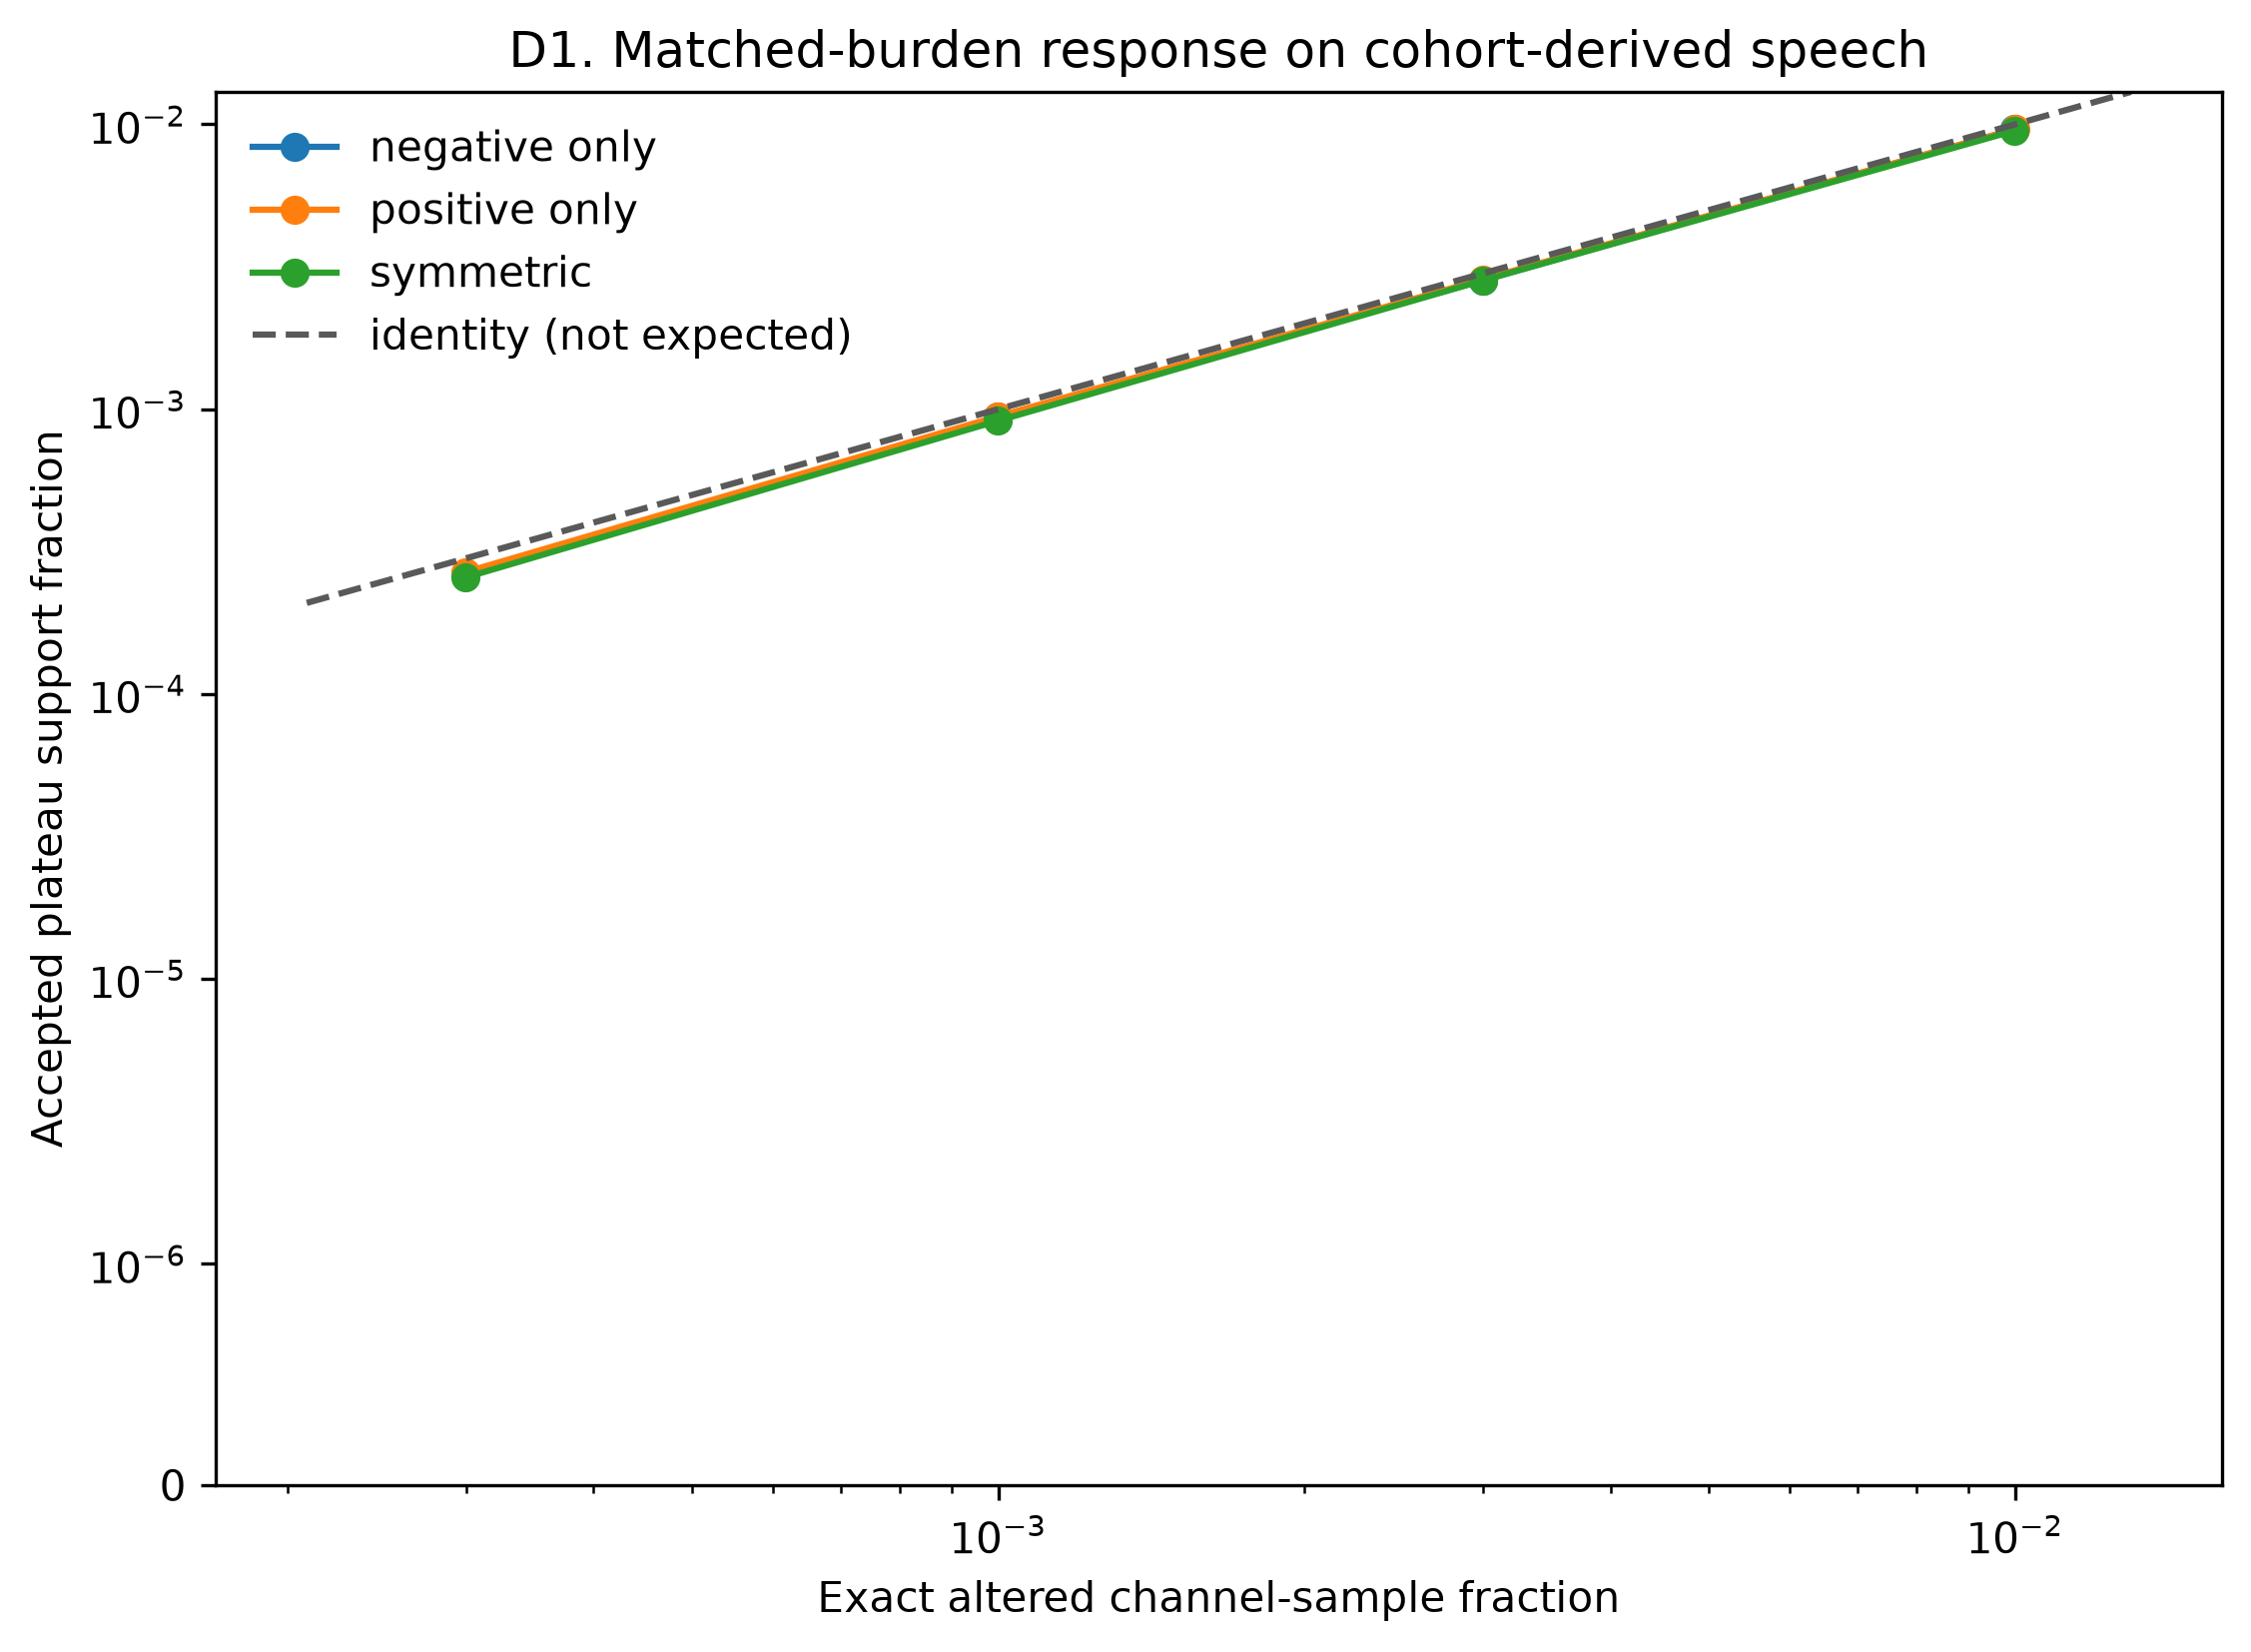

### Panel D2

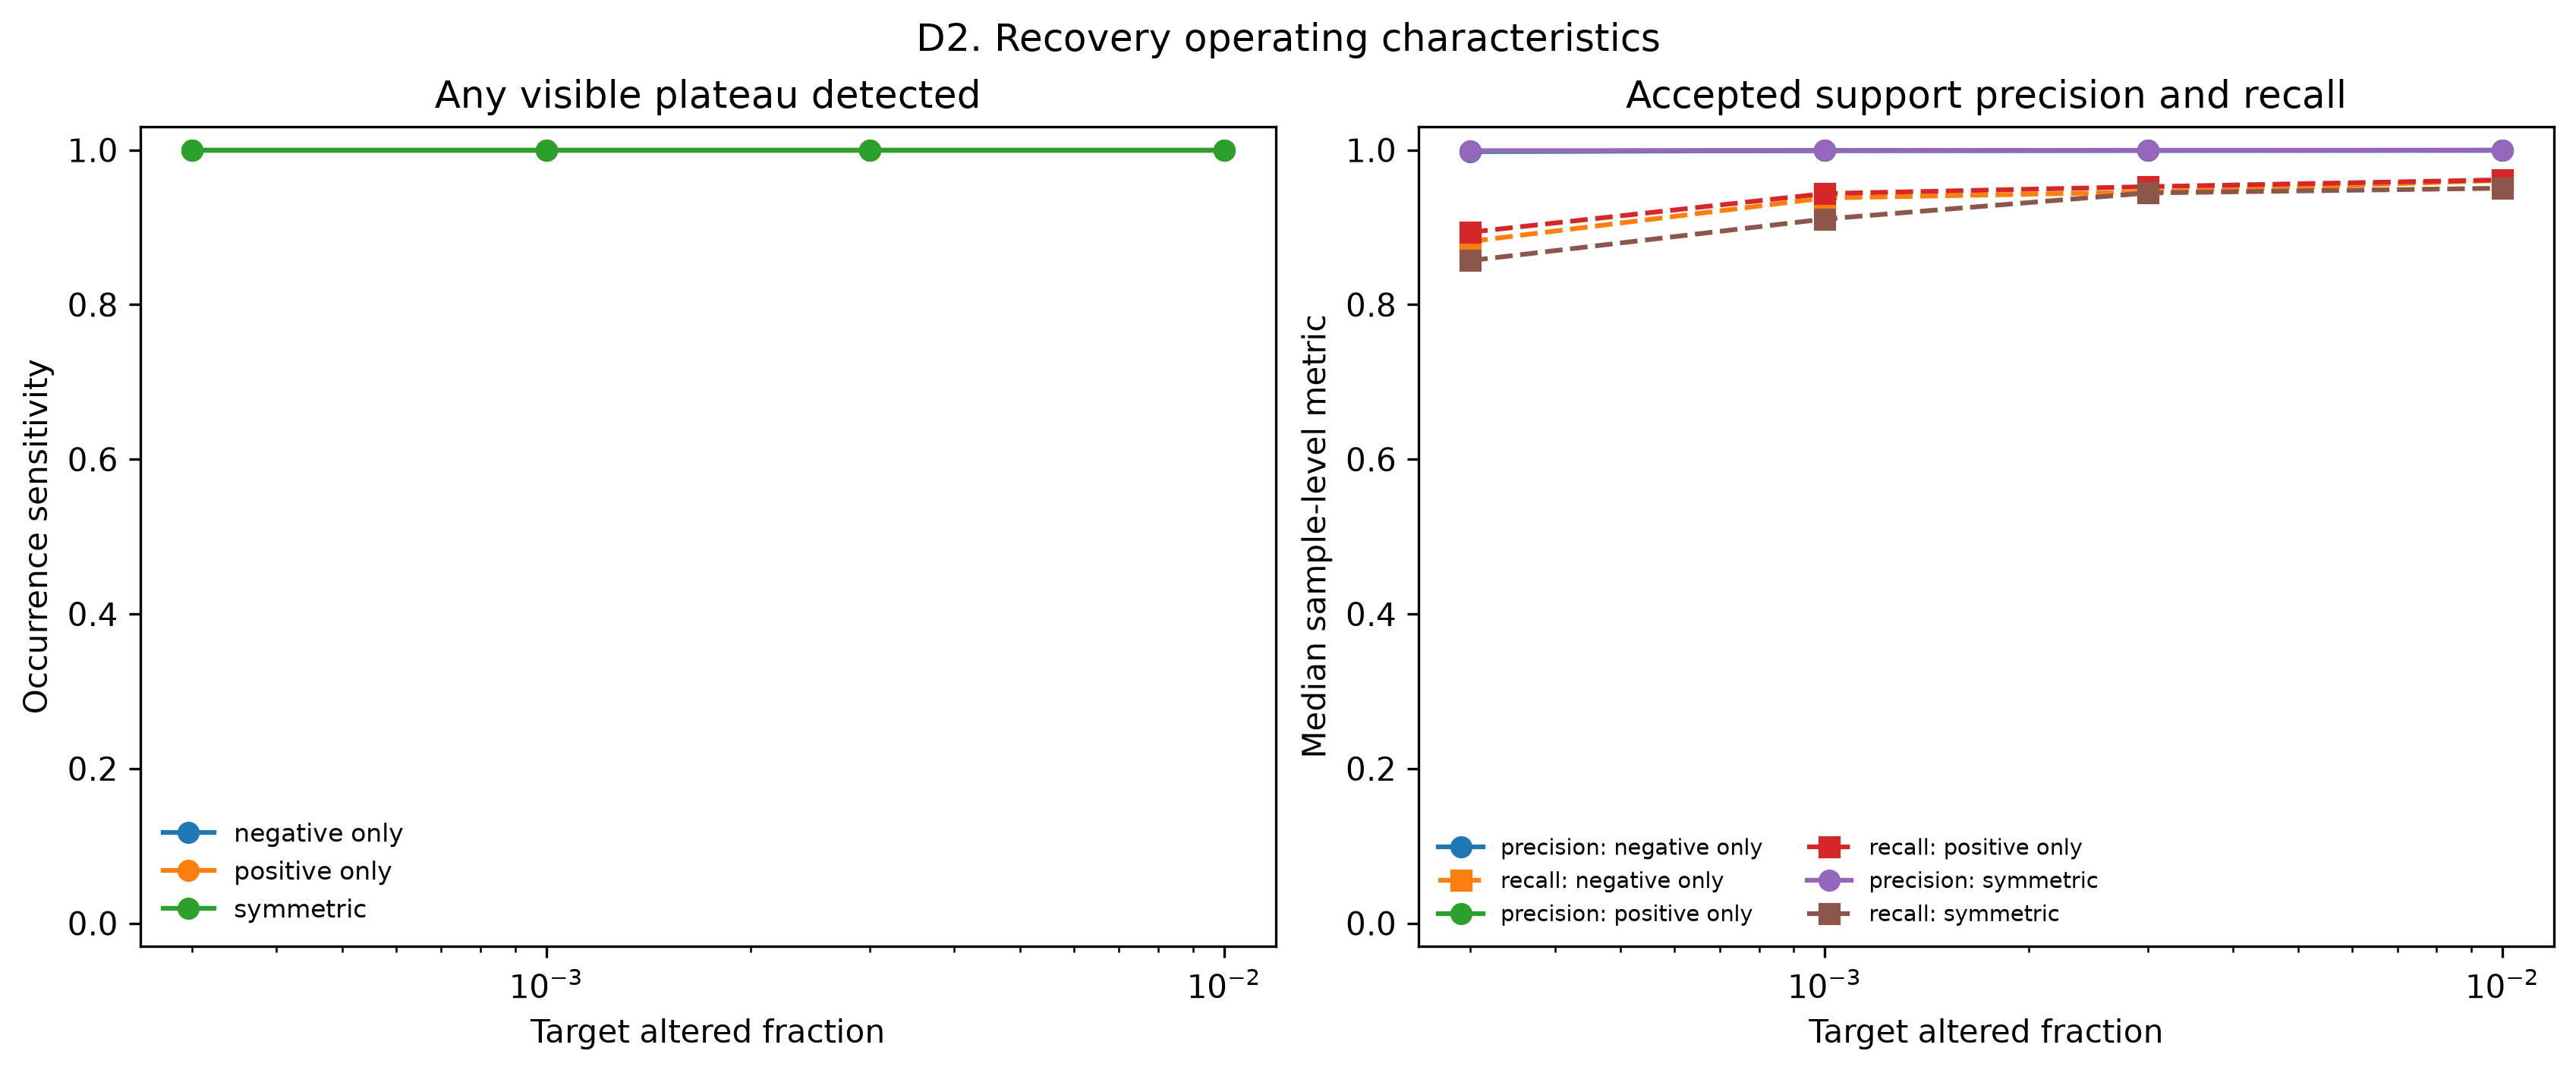

### Panel D3

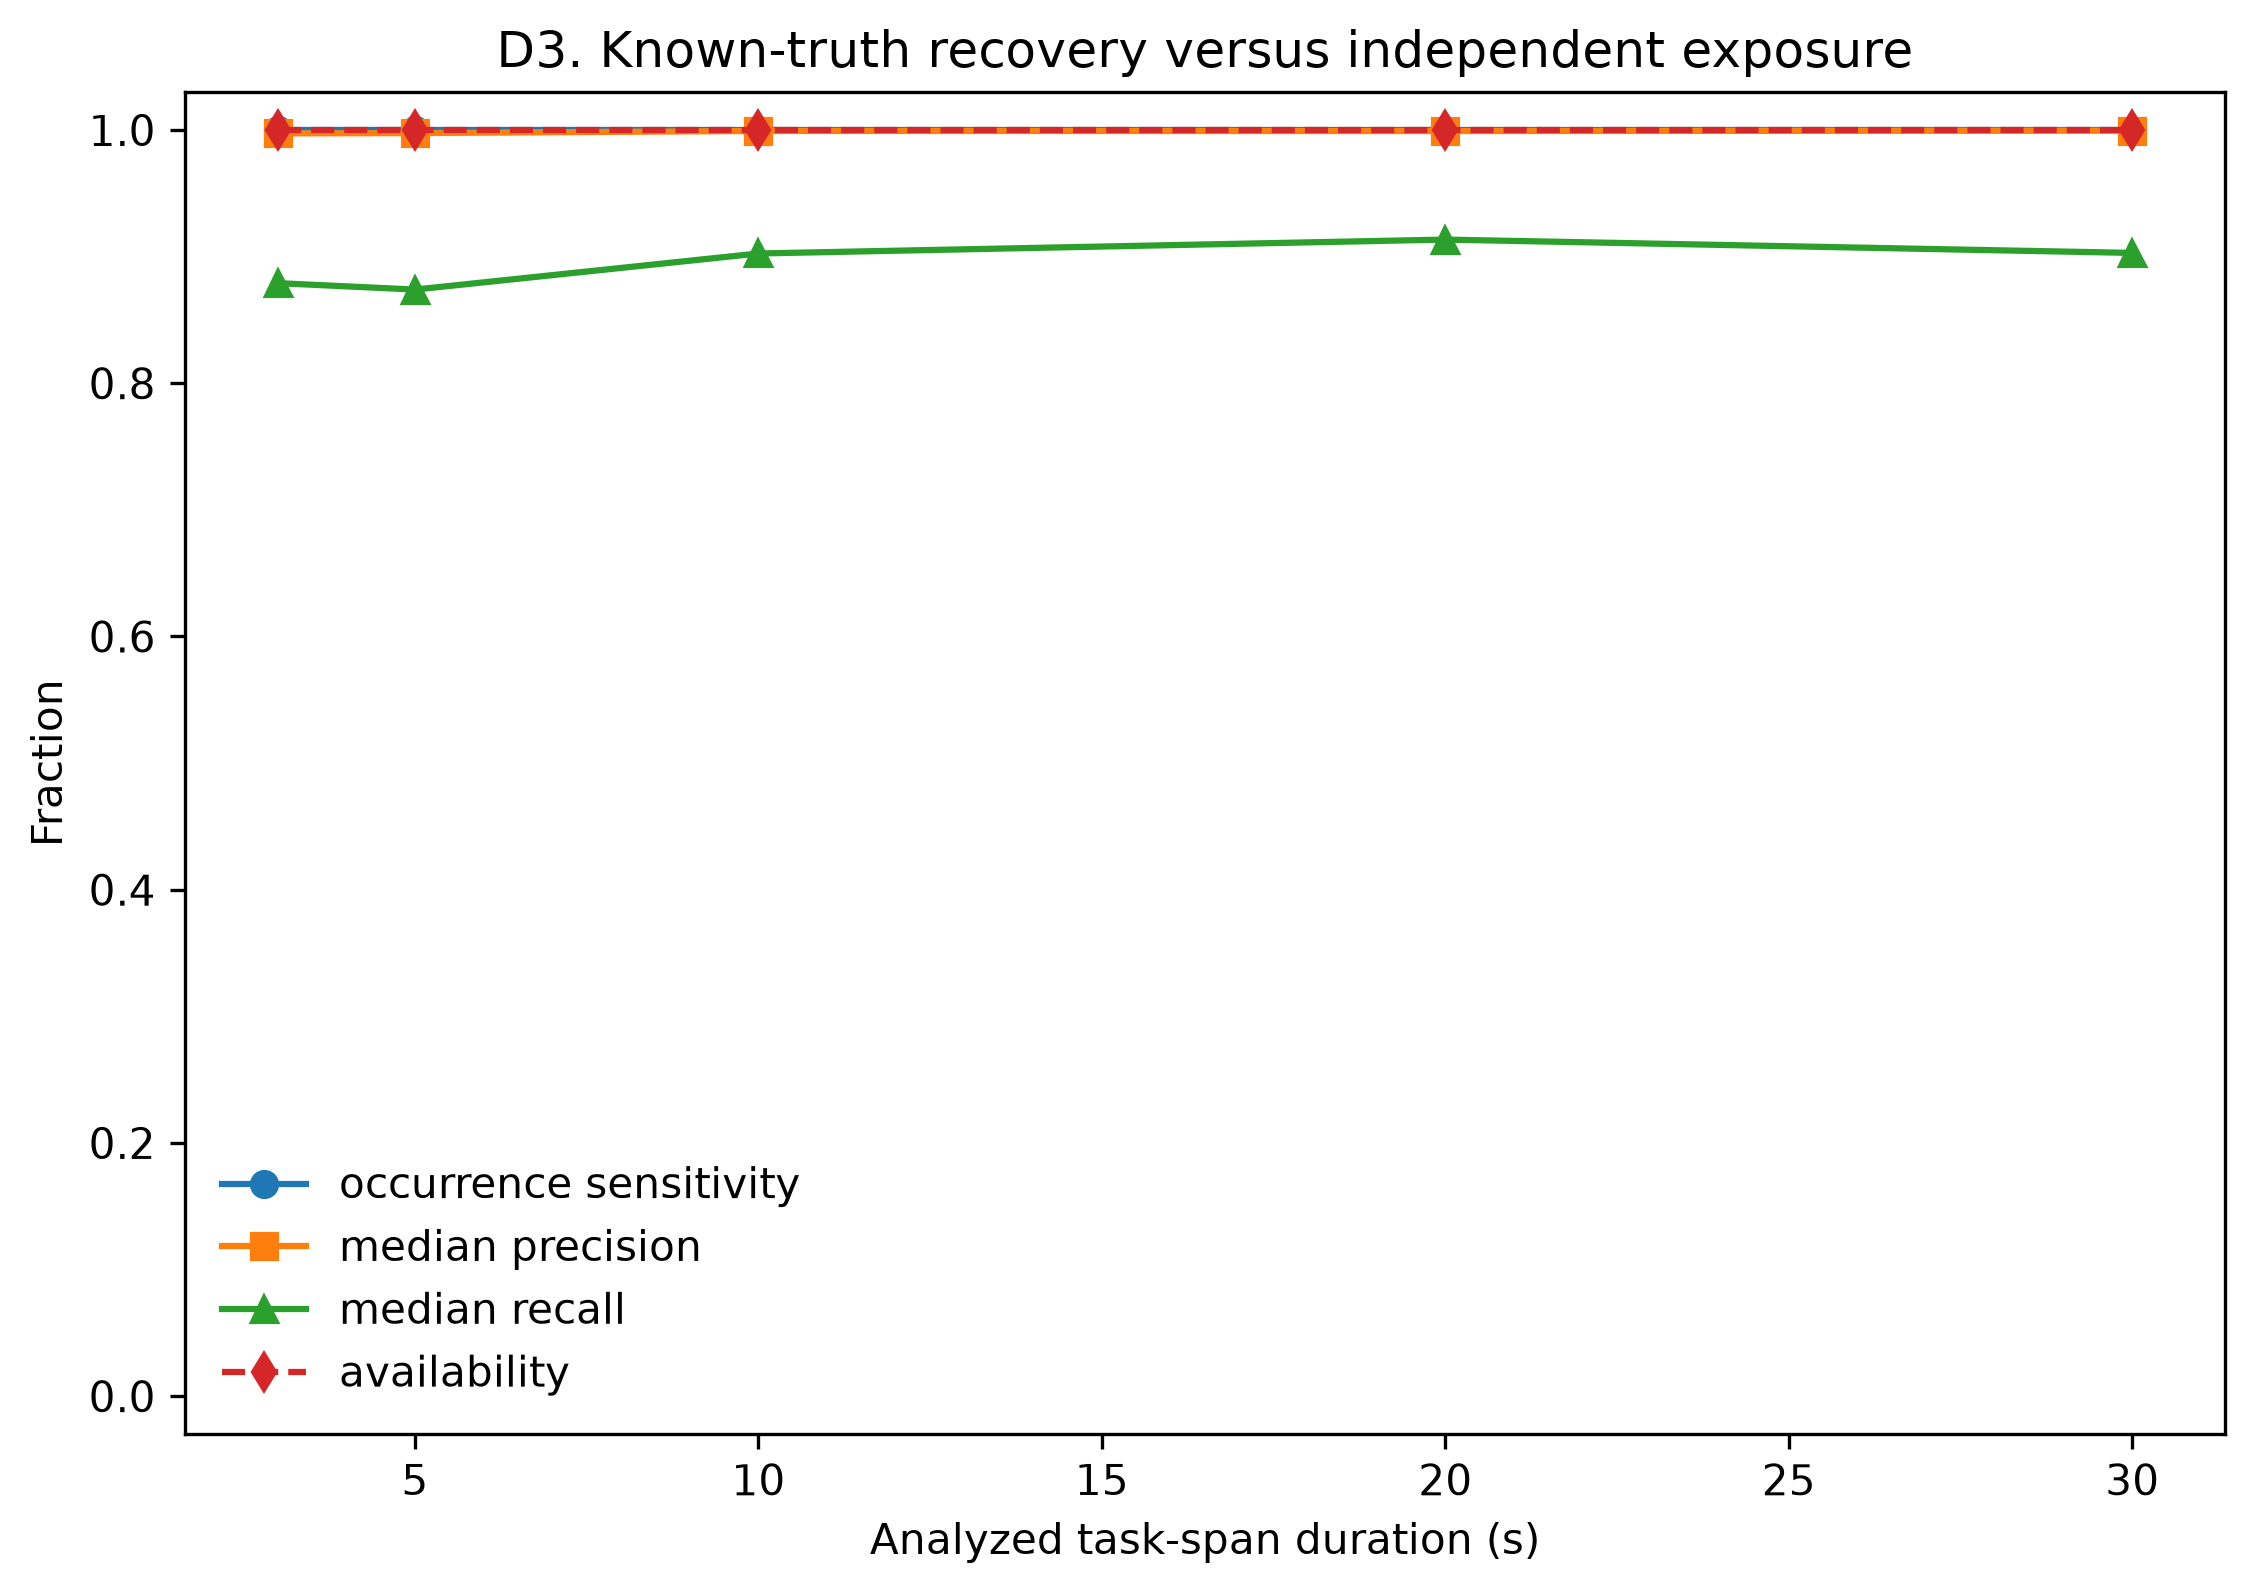

### Panel F

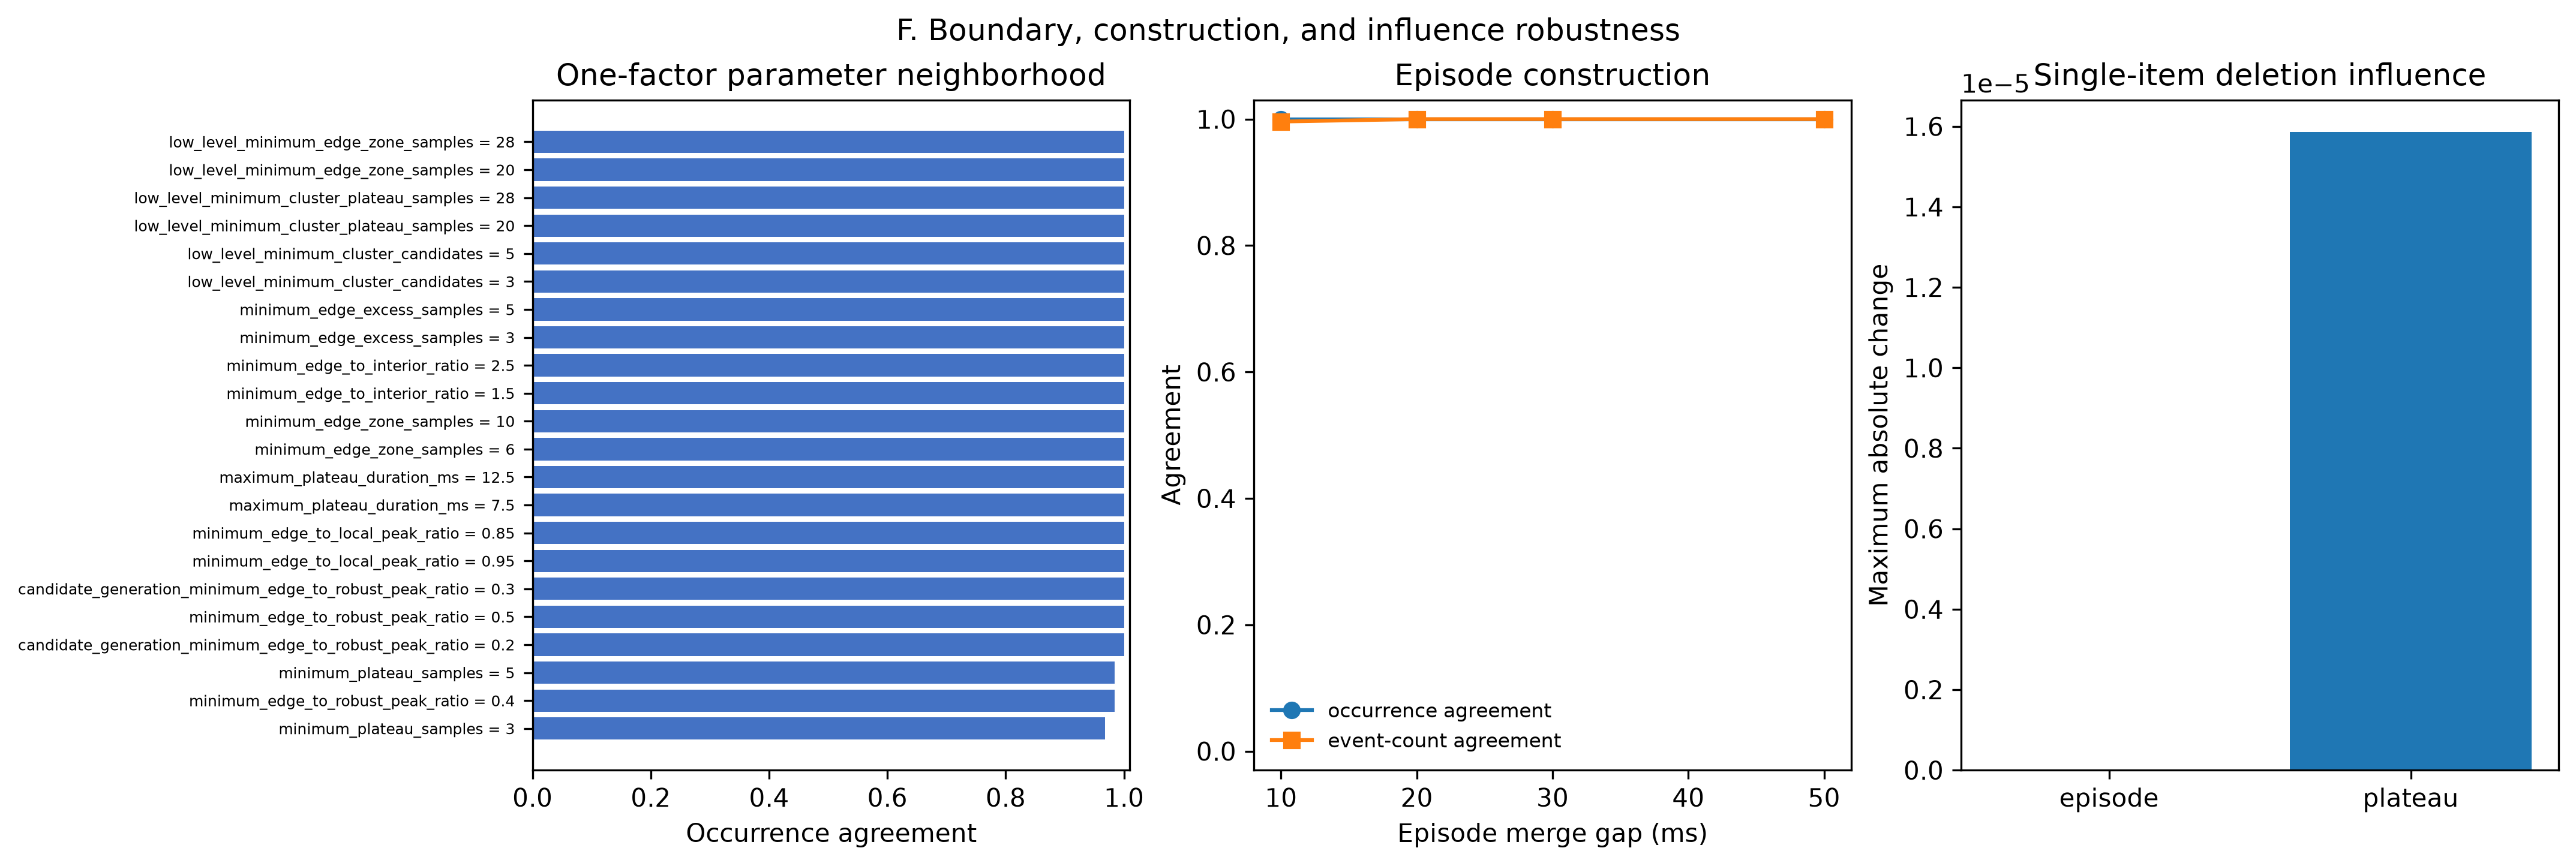

### Panel I

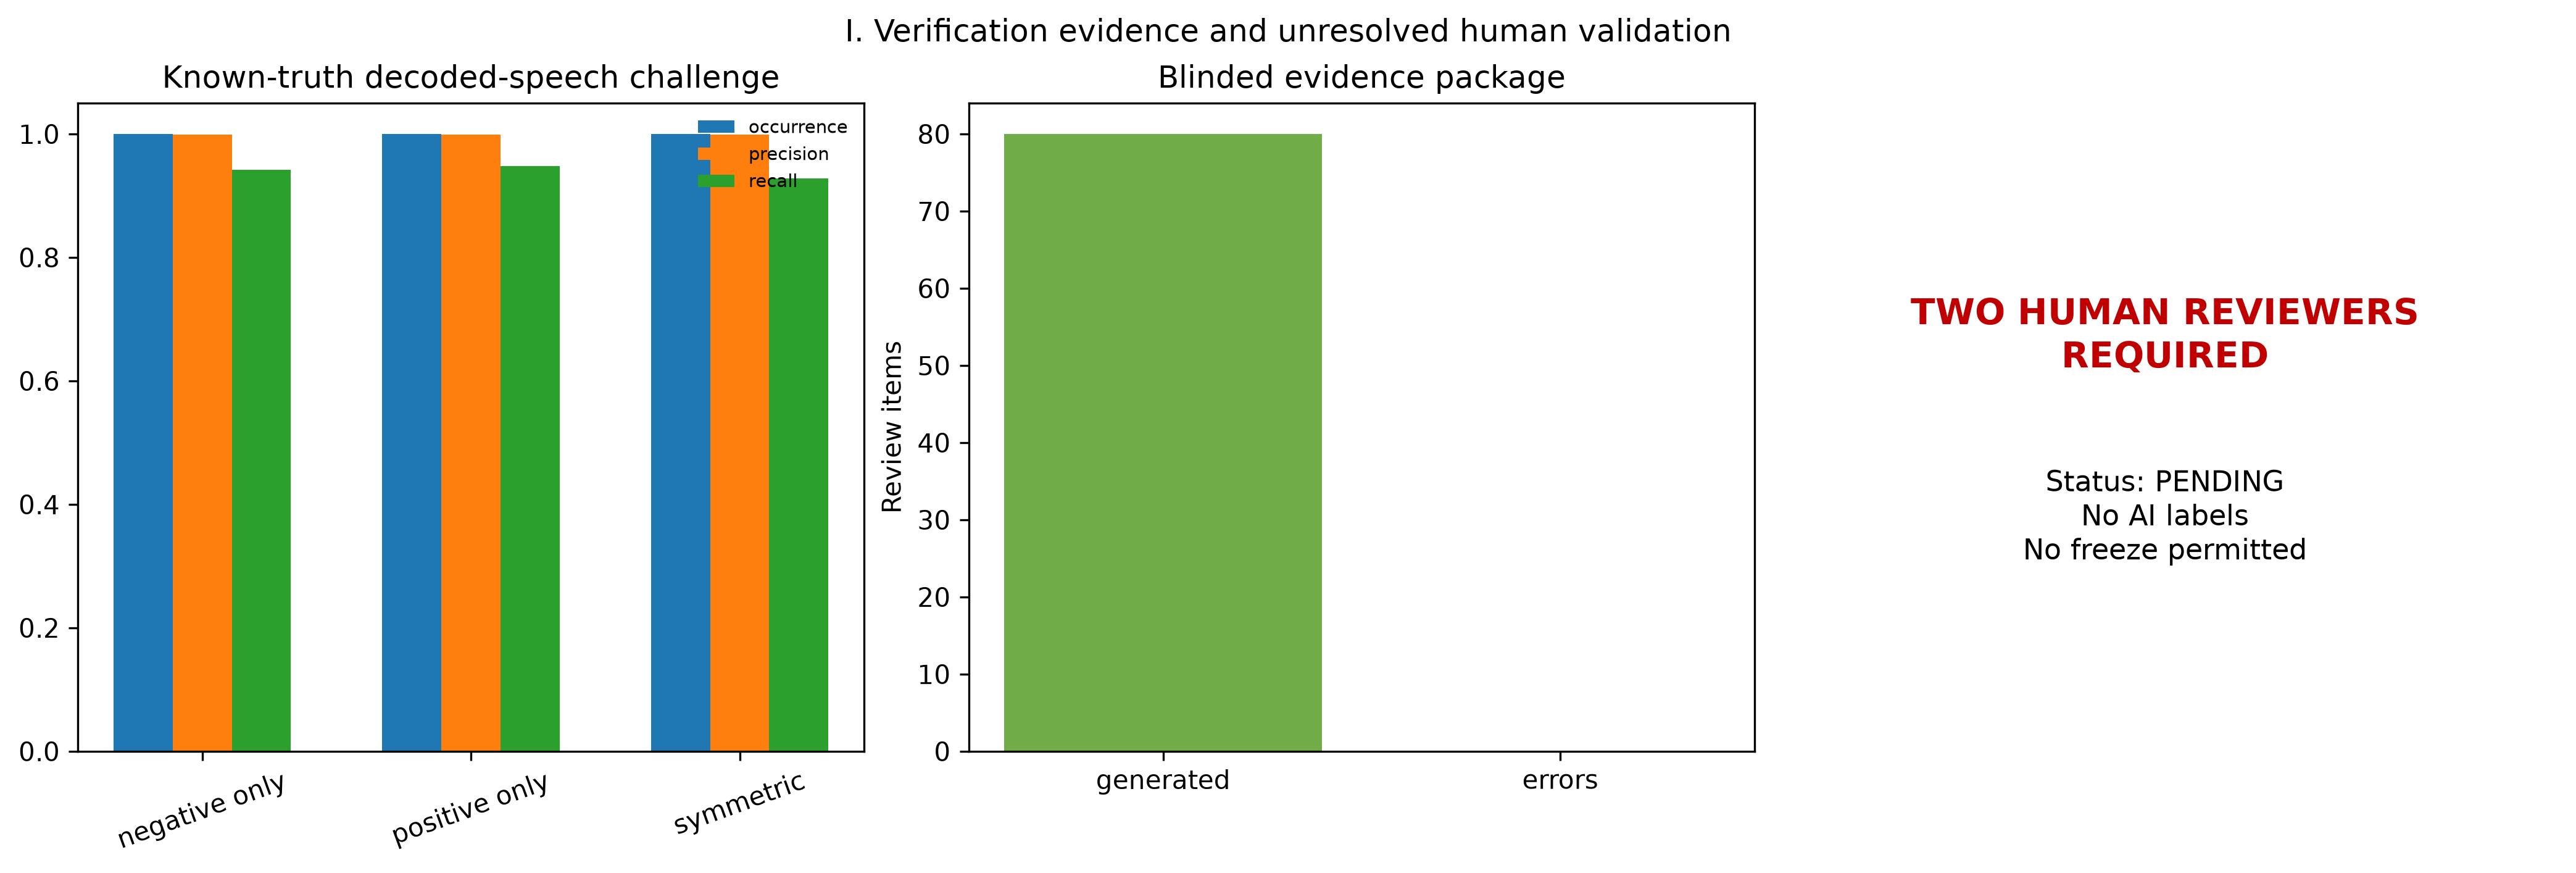

### Panel J

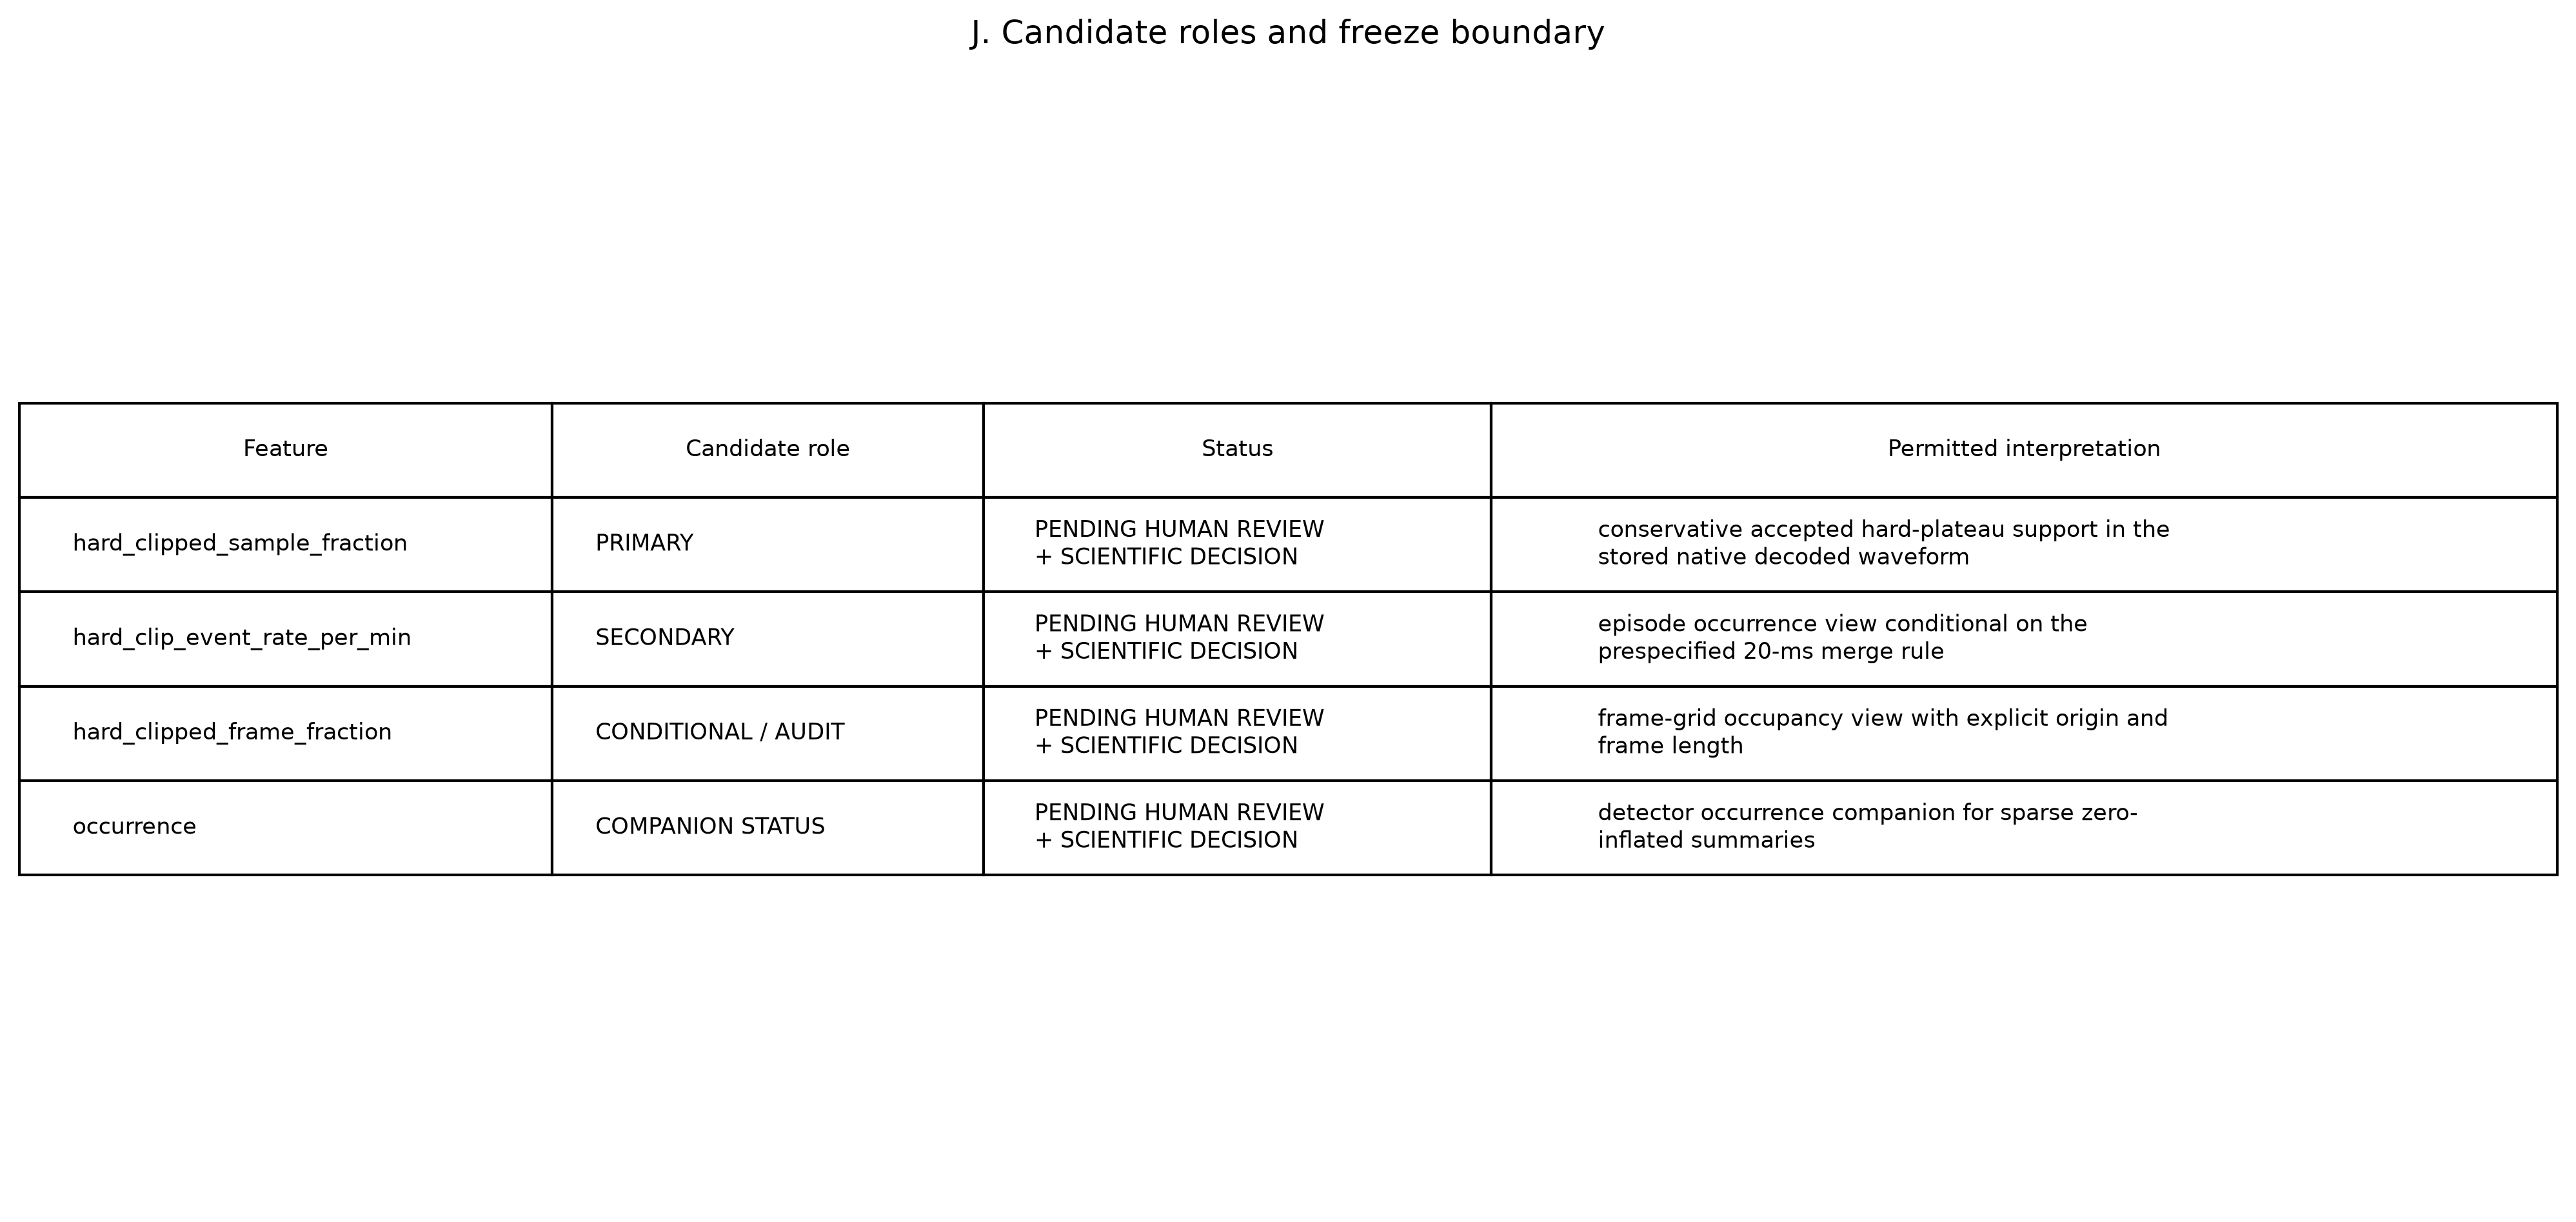

In [8]:
figure_index = result['figure_index']
display(figure_index[['panel', 'stem', 'bundle_role', 'png', 'source_csv', 'caption', 'provenance']])
for panel in ['D1', 'D2', 'D3', 'F', 'I', 'J']:
    row = figure_index.loc[figure_index['panel'].eq(panel)].iloc[0]
    display(Markdown(f'### Panel {panel}'))
    display(Image(filename=str(paths.output_root / row['png']), width=1100))

## Required next stage: two independent human reviewers

The generated review package contains every accepted plateau, near-threshold rejections, and deterministic valid-zero windows. Give each reviewer a separate copy of the corresponding template and the `items` folder. Reviewers must not open `restricted/qdist_v410_blind_review_key.csv` and must not compare sheets until both are complete.

In [9]:
review_root = paths.output_root / 'blind_review'
review_files = [
    review_root / 'README_BLINDED_REVIEW.md',
    review_root / 'reviewer_1_TEMPLATE.csv',
    review_root / 'reviewer_2_TEMPLATE.csv',
    review_root / 'qdist_v410_blind_review_index.csv',
]
for path in review_files:
    print(path, 'OK' if path.exists() else 'MISSING')
print('Review items:', len(result['review_index']))
print('HUMAN REVIEW STATUS:', result['manifest']['human_morphology_review_status'])

C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs/02_FEATURE_REVIEWED/00_working_candidates\nonlinear_distortion\qdist_v410_candidate_cohort\blind_review\README_BLINDED_REVIEW.md OK
C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs/02_FEATURE_REVIEWED/00_working_candidates\nonlinear_distortion\qdist_v410_candidate_cohort\blind_review\reviewer_1_TEMPLATE.csv OK
C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs/02_FEATURE_REVIEWED/00_working_candidates\nonlinear_distortion\qdist_v410_candidate_cohort\blind_review\reviewer_2_TEMPLATE.csv OK
C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs/02_FEATURE_REVIEWED/00_working_candidates\nonlinear_distortion\qdist_v410_candidate_cohort\blind_review\qdist_v410_blind_review_index.csv OK
Review items: 80
HUMAN REVIEW STATUS: PENDING_TWO_INDEPENDENT_REVIEWERS


## Stop boundary

This notebook ends at candidate evidence. Do not copy its candidate interface into a publication freeze. After two completed reviews, run the separate adjudication notebook, inspect disagreements and failure modes, make explicit retain/revise/conditional/drop decisions, reconcile the manuscript census, and only then design a separate immutable freeze workflow.